# 3.6: Model performance comparison
This notebook will assess the performance of the models generated in step 3.3, 3.4 and 3.5. 

## 3.6.1 system setup

In [ ]:
import pandas as pd
import os
import sys
sys.path.append('../../utils')
from  configloader import Configloader
import cnn_helpers
import implot
import file_io
import numpy as np
import matplotlib.pyplot as plt
import json

#from sklearn.preprocessing import LabelEncoder
#import tensorflow as tf

from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score

2025-04-04 11:08:44.989504: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE3 SSE4.1 SSE4.2 AVX AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [4]:
cnn_helpers.system_override()
device = cnn_helpers.system_pick_device()

System override applied - check if GPU is detected
Using GPU for deep learning.


2025-04-04 11:08:49.258533: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-04 11:08:51.518402: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero
2025-04-04 11:08:51.518472: I external/local_xla/xla/stream_executor/rocm/rocm_executor.cc:920] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero


In [5]:
config = Configloader()

basedir = config.get('settings', 'image_directory')
csv_data_dir = config.get('dir_augmentations', 'csv_dir')

#augment_base = os.path.join(basedir, 'augmentated data', 'brand phase')


In [8]:
SHAPE = 224

PHASE = 'brand phase'

MODELDIR = os.path.join(
    config.get('directories', 'root_dir'), 
    config.get('directories', 'final_models_dirname'), 
    config.get('directories', 'brandphase'),
    config.get('directories', 'angled')
    )

CROP = True  #crop on bbox
PBS = 1024 #Predict Batch Size (size of the batch of numpy arrays to do predictions on)

#read and/or store inferred performance results (will store in MODELDIR). 
STORE_INFER = True
READ_INFER = True
INFER_PATH = os.path.join(MODELDIR, 'inferred_results')

In [ ]:
csv_dir = os.path.join(basedir, csv_data_dir, PHASE)  #where the train/test/valid split in step 3.1 was done.

## 3.6.2 Data loading
This notebook will use NON-augemented data from the validation set! 

In [5]:
validation_df_path = os.path.join(csv_dir, 'validationdata_brandphase.csv')
validation_df = pd.read_csv(validation_df_path)

In [6]:
validation_df = cnn_helpers.shuffle_df(validation_df)
validation_df

,image_id,model_label,model_score,yolobox_top_left_x,yolobox_top_left_y,yolobox_bottom_right_x,yolobox_bottom_right_y,bintag_predicts.image_id,model1_results,model2_results,model3_results,model4_results,brand,abs_path
0,16063132,rear,1.000000,114,39,673,400,16063132,0.988936,0.999575,0.672129,0.519338,bmw,/home/frederic/Documents/automotive_image_data...
1,7610326,front,1.000000,123,106,619,501,7610326,0.805689,1.000000,0.998526,0.997112,opel,/home/frederic/Documents/automotive_image_data...
2,9110530,rearleft,0.725958,30,66,692,464,9110530,0.979823,1.000000,0.997124,0.990440,bmw,/home/frederic/Documents/automotive_image_data...
3,5401032,front,0.999973,-1,-1,-1,-1,5401032,0.283884,0.999859,0.907065,0.040246,mercedes-benz,/home/frederic/Documents/automotive_image_data...
4,14408598,frontright,1.000000,103,179,644,498,14408598,0.995743,0.999975,0.989605,0.996390,peugeot,/home/frederic/Documents/automotive_image_data...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
399056,5806579,frontleft,1.000000,111,222,658,495,5806579,0.989293,0.999442,0.984773,0.996976,mercedes-benz,/home/frederic/Documents/automotive_image_data...
399057,13974853,frontleft,1.000000,20,50,715,442,13974853,0.991376,0.086397,0.007257,0.990583,renault,/home/frederic/Documents/automotive_image_data...
399058,9015786,frontright,1.000000,85,154,682,485,9015786,0.916666,0.982382,0.392153,0.368413,bmw,/home/frederic/Documents/automotive_image_data...
399059,15282655,right,0.999938,9,85,715,409,15282655,0.450382,0.987389,0.909929,0.658155,toyota,/home/frederic/Documents/automotive_image_data...


In [7]:
def quickplot(key):
    value_counts = validation_df[key].value_counts()
    plt.bar(value_counts.index, value_counts.values)
    plt.xticks(rotation=90) 
    return plt

''

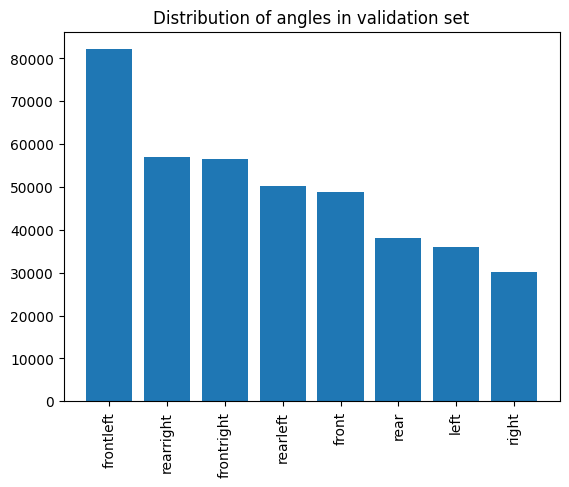

In [8]:
g = quickplot('model_label')
g.title('Distribution of angles in validation set')
;

''

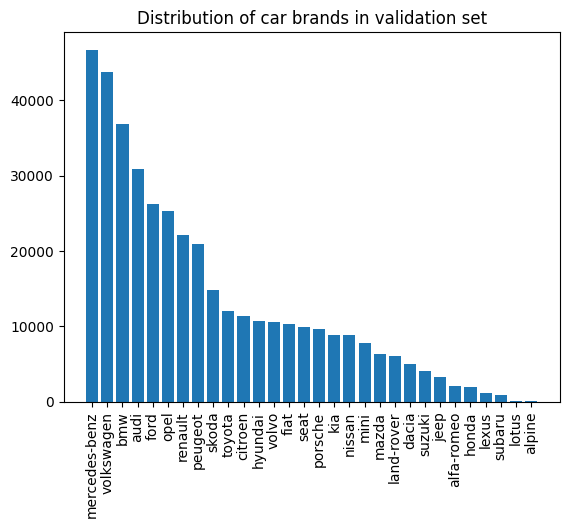

In [9]:
g = quickplot('brand')
g.title('Distribution of car brands in validation set')
;

this is good - we still remember the graphs made in EDA phases and post-applier notebooks that showed similar distributions. Now assess the models. 

## 3.6.3 please note: 
Note that we already have the model tag stored in the CSV generated by the notebook `/notebooks/model appliers/2 - apply_angletag.ipynb`. We'll aplly all models to all images and compare what works best: use the angle-specific model or use the highest performing output. 


In [10]:
decode_labels = {}

## 3.6.4 Performance assessment of angle based brand models (signle infer)
The highly specialized models that are trained on specific angles are probably very good at inferring the brand from an image if the angle is correclty inferred in phase 2. However, this is not always the case (that model did not perform at an F1 of 100%). In subsection `3.6.3` we will only infer on the angle model that the angle-tagger expects. 

In [30]:
single_infer_predicts = {}

In [ ]:
single_infer_filename = 'single_infer.json'
single_infer_filepath = os.path.join(INFER_PATH, single_infer_filename)
if READ_INFER and os.file.exists(single_infer_filepath): 
    single_infer_predicts = json.load(single_infer_filepath)
    print('INFERENCE RESULTS READ FROM DISK')
else: 
    print('RUNNING INFERRENCE')
    for angle_folder in os.listdir(MODELDIR): 
        dir = os.path.join(MODELDIR, angle_folder)
        dircontent = os.listdir(dir)
        labeldict = [f for f in dircontent if f.endswith('.json')][0]
        subslice_validation = validation_df.query(f'model_label == "{angle_folder}"')
        with open(os.path.join(dir,labeldict), 'r') as f:
            le = json.load(f)
            le = {int(k): v for k,v in le.items()}
        decode_labels[angle_folder] = le

        predicts = []
        actuals = []
        model = cnn_helpers.load_one_model(dir)

        print(f'{angle_folder}: Starting batch processing...')
        l = len(subslice_validation)
        for i in range(0, l, PBS):
            print(f'{i} of {l}', end='\r')
            batch_df = subslice_validation.iloc[i:i + PBS]
            X_val_images = []
            y_targets = []

            # Preprocess images in the current batch
            for _, row in batch_df.iterrows():
                coords = [row['yolobox_top_left_x'], row['yolobox_top_left_y'], row['yolobox_bottom_right_x'], row['yolobox_bottom_right_y']]
                image = cnn_helpers.preprocess_image(row['abs_path'], CROP, coords, SHAPE)
                X_val_images.append(image)
                y_targets.append(row['brand'])

            X_val_images = np.array(X_val_images)

            # Predict for the current batch
            batch_predicts = model.predict(X_val_images, verbose=0)
            predicts.extend(batch_predicts)
            actuals.extend(y_targets)

        print('Inference done for', angle_folder)
        single_infer_predicts[angle_folder] = {
            'predicts': predicts, 
            'actuals': actuals
        }
    if STORE_INFER: 
        file_io.dict_to_json_file(
            cnn_helpers.convert_ndarrays_to_lists(single_infer_predicts), 
            INFER_PATH, 
            single_infer_filename
        )

        

rearright: Starting batch processing...
Inference done for rearright
frontright: Starting batch processing...
Inference done for frontright
rearleft: Starting batch processing...
Inference done for rearleft
front: Starting batch processing...
Inference done for front
left: Starting batch processing...
Inference done for left
rear: Starting batch processing...
Inference done for rear
right: Starting batch processing...
Inference done for right
frontleft: Starting batch processing...
Inference done for frontleft


In [ ]:


def quickrun_metrics(act, pred): 
    metrics = {
        'Accuracy': accuracy_score(act, pred),
        'Macro F1 Score': f1_score(act, pred, average='macro'),
        'Weighted F1 Score': f1_score(act, pred, average='weighted'),
        'Cohen\'s Kappa': cohen_kappa_score(act, pred)
    }
    return metrics


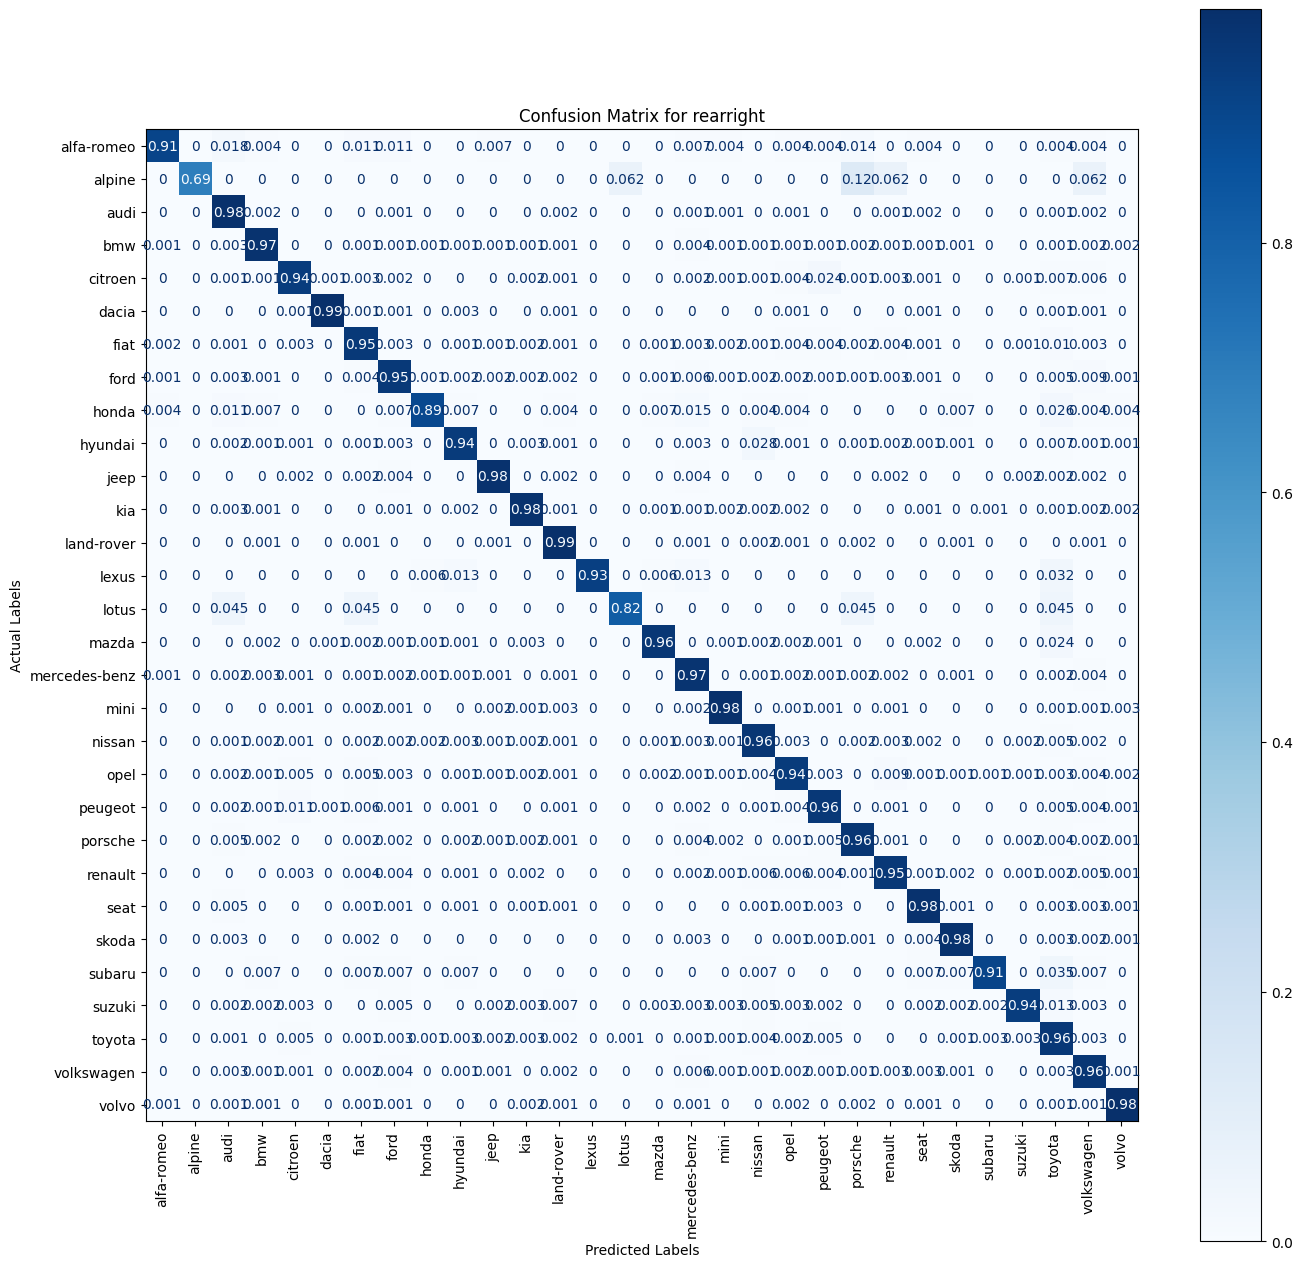

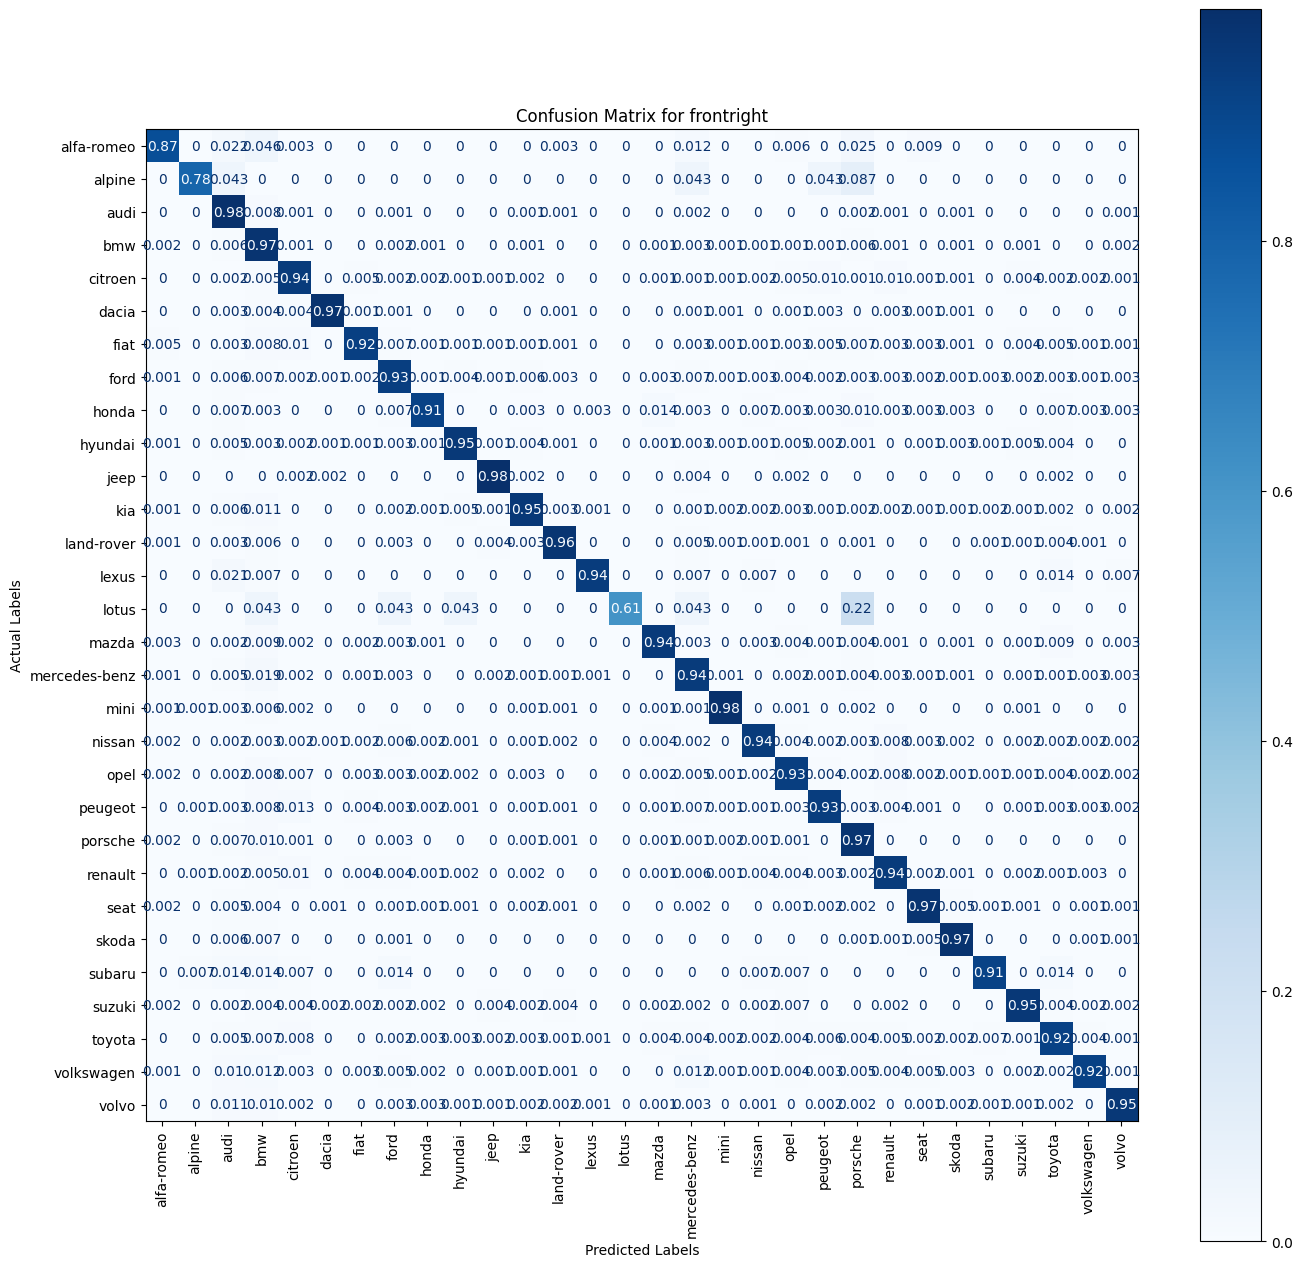

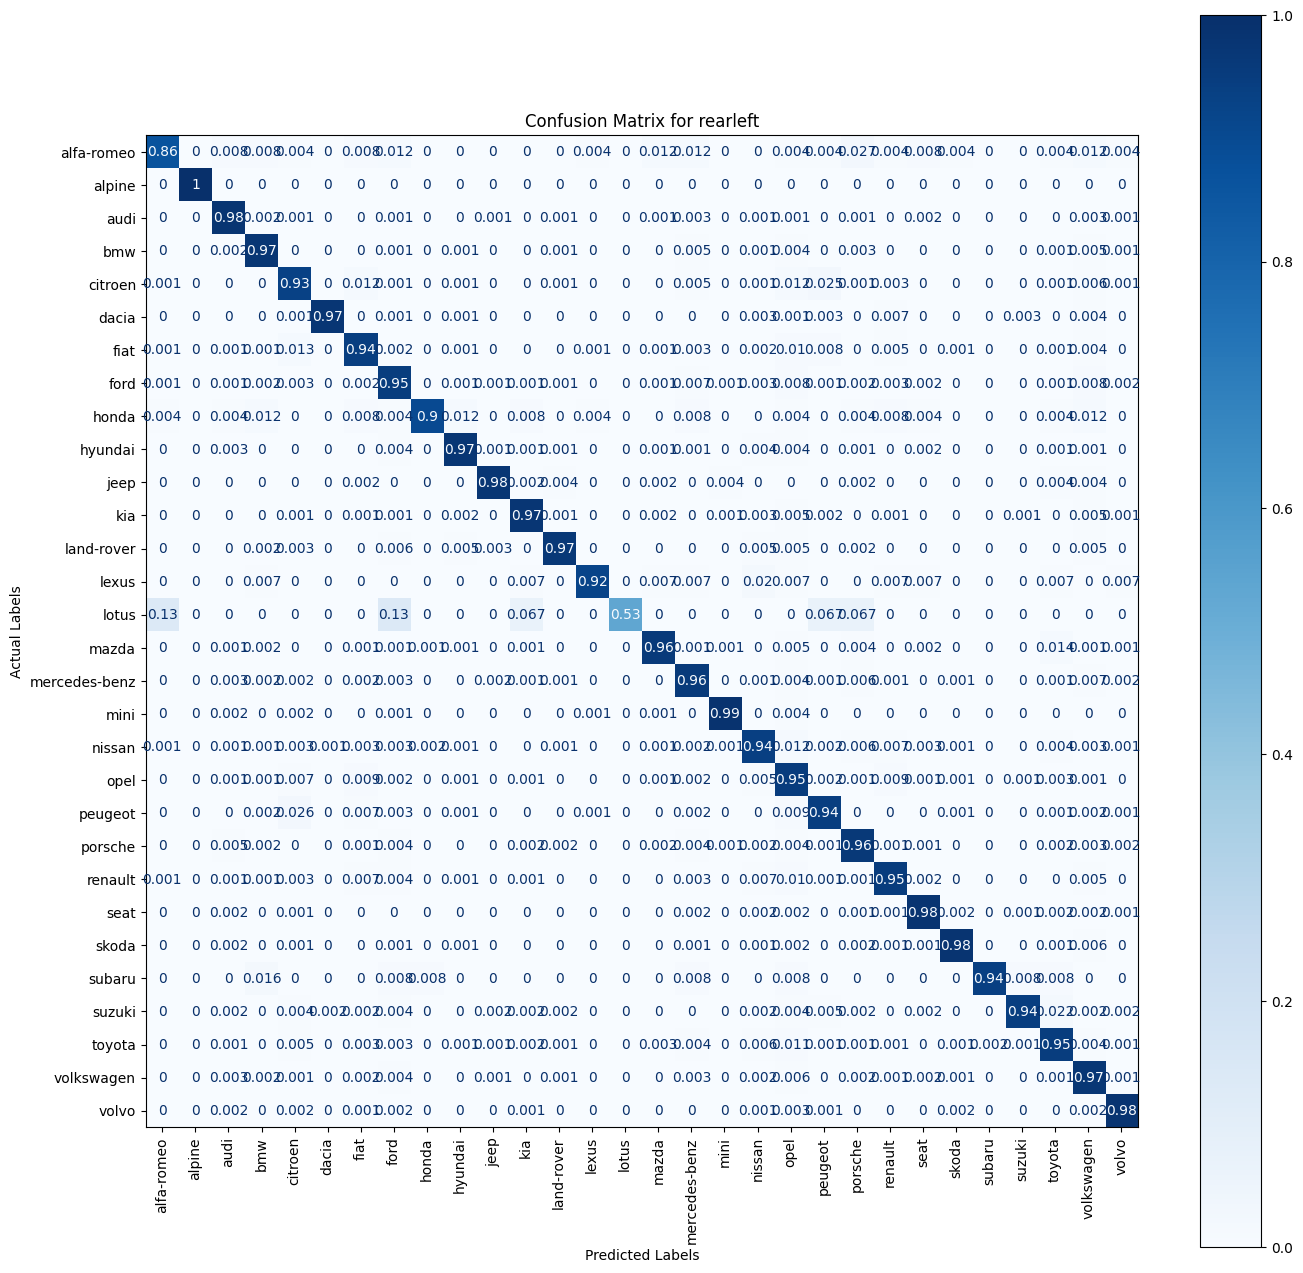

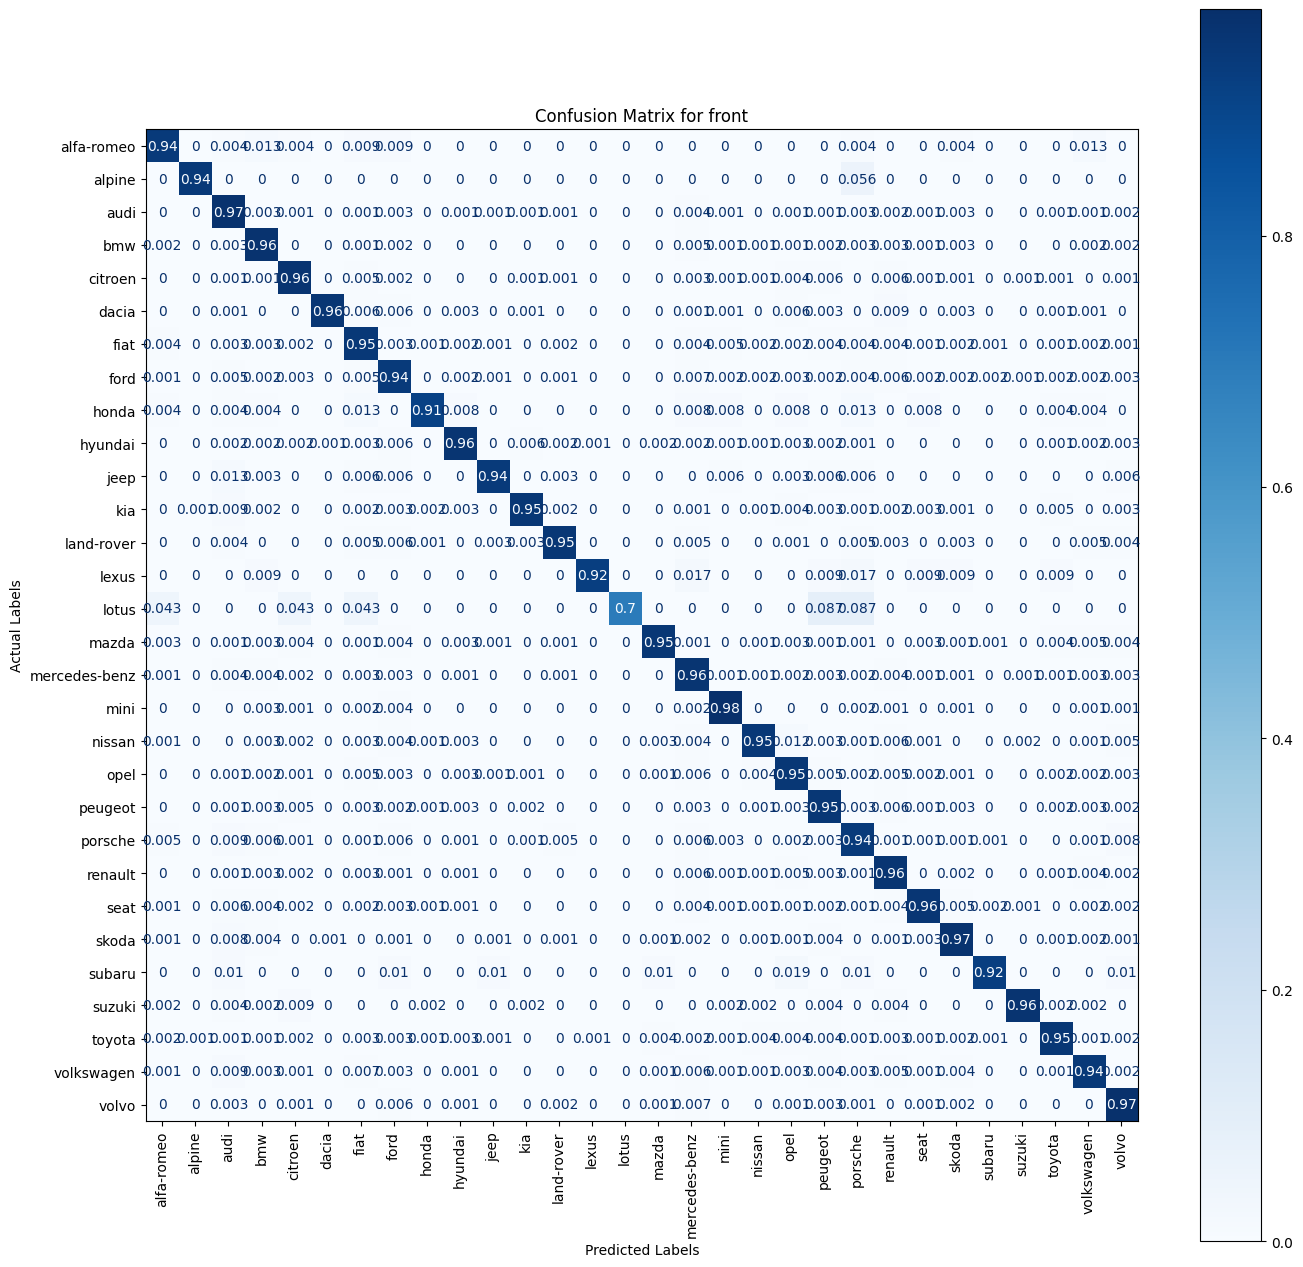

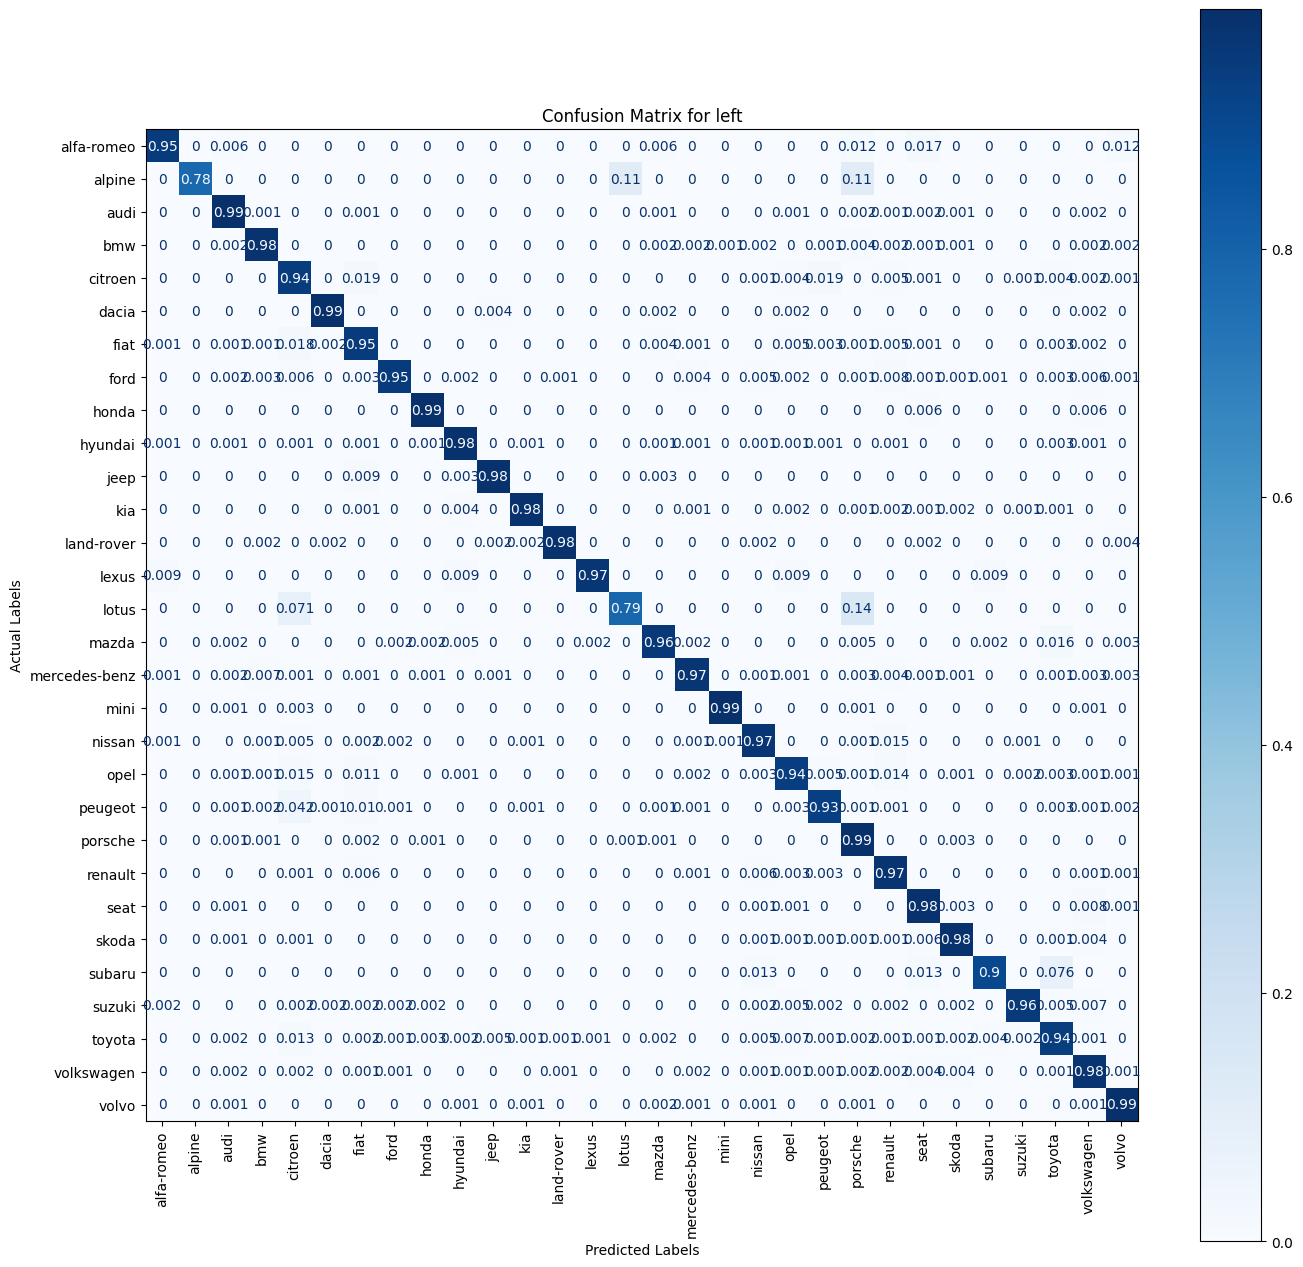

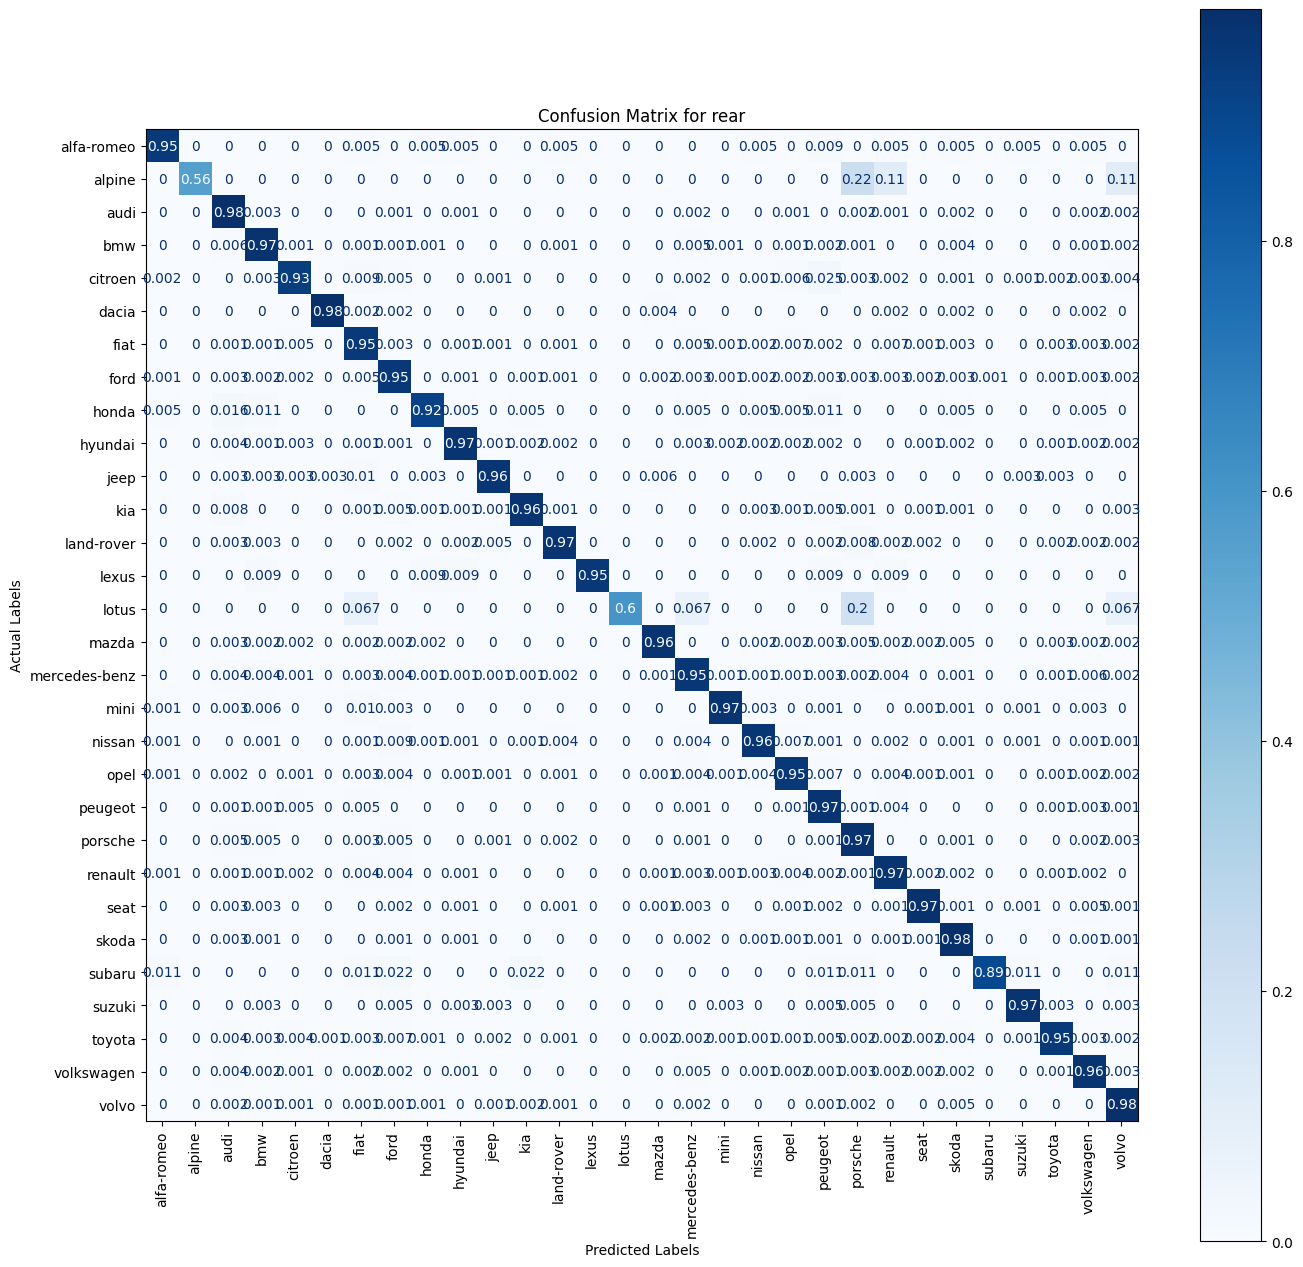

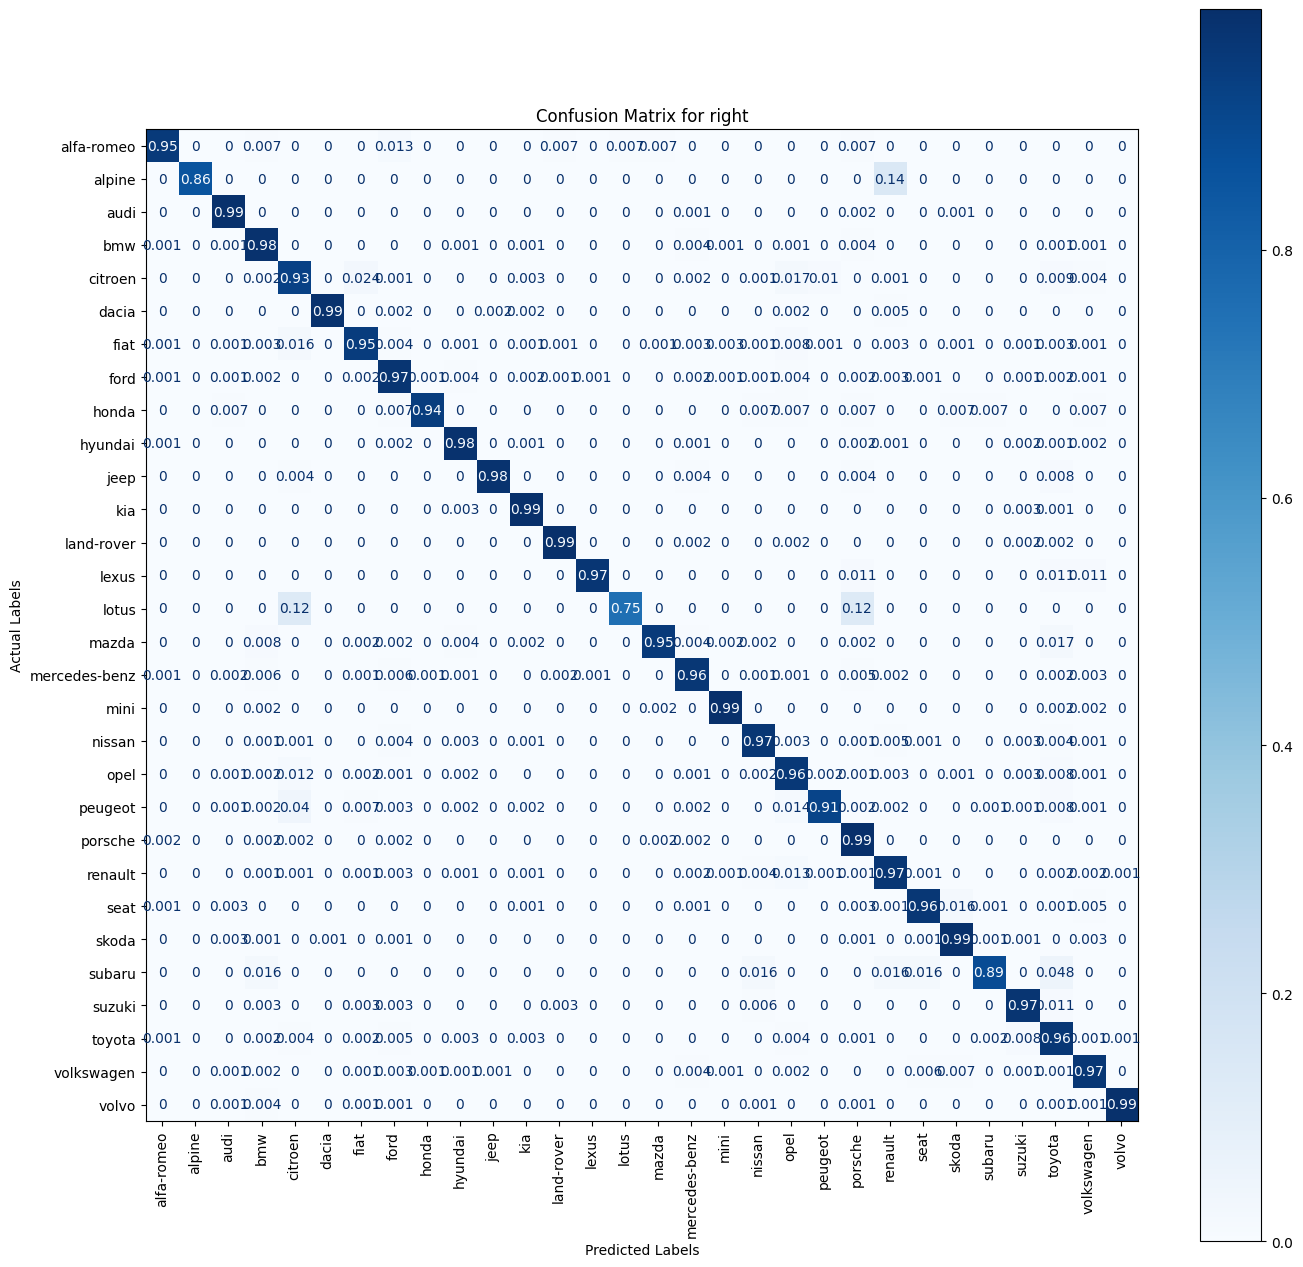

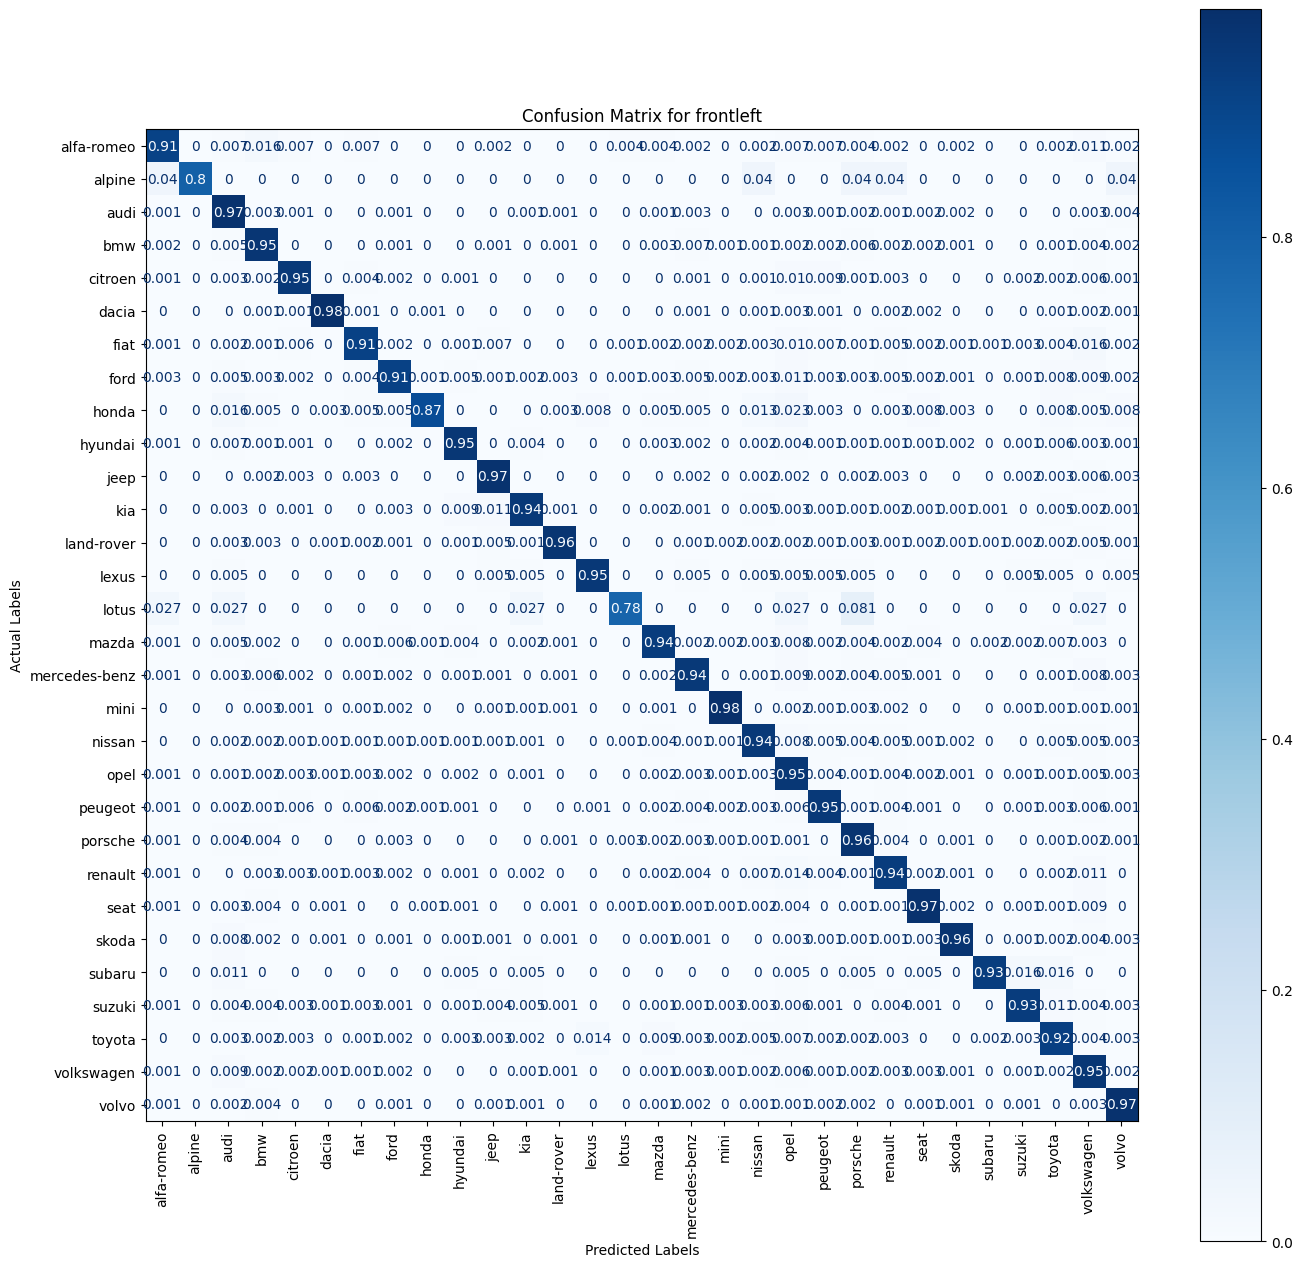

In [ ]:
pooled_actuals = []
pooled_predicts = []
angle_metrics = {}
for angle, valresults in single_infer_predicts.items(): 
    encoded_prediction_labels = np.argmax(valresults['predicts'], axis=1)
    decoded_labels = [decode_labels[angle][i] for i in encoded_prediction_labels]
    brand_names = decode_labels[angle].values()
    act = valresults['actuals']
    pred = decoded_labels
    pooled_actuals.extend(act)
    pooled_predicts.extend(pred)
    cm = implot.make_cm(act, pred, brand_names)
    angle_metrics[angle] = quickrun_metrics(act, pred)
    cm.title(f"Confusion Matrix for {angle}")
    cm.show()

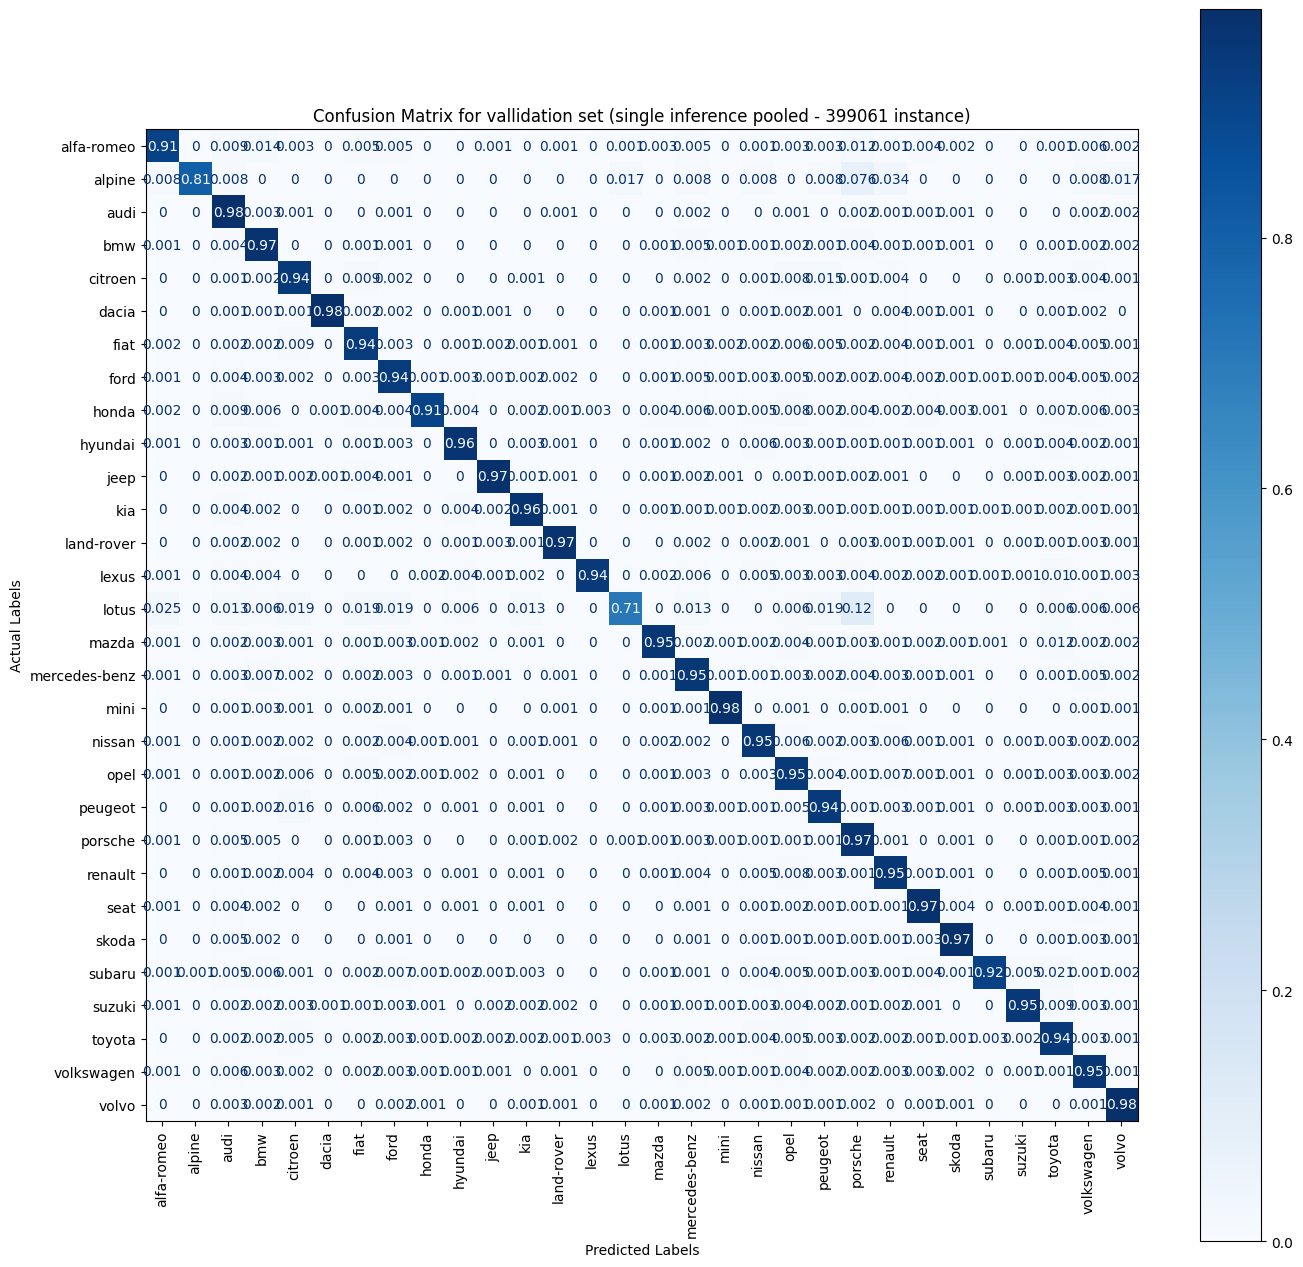

In [ ]:
# Pooled single inference performance: 
cm = implot.make_cm(pooled_actuals, pooled_predicts, brand_names)
cm.title(f"Confusion Matrix for vallidation set (single inference pooled - {len(pooled_actuals)} instances)")
cm.show()
angle_metrics['pooled'] = quickrun_metrics(pooled_actuals, pooled_predicts)


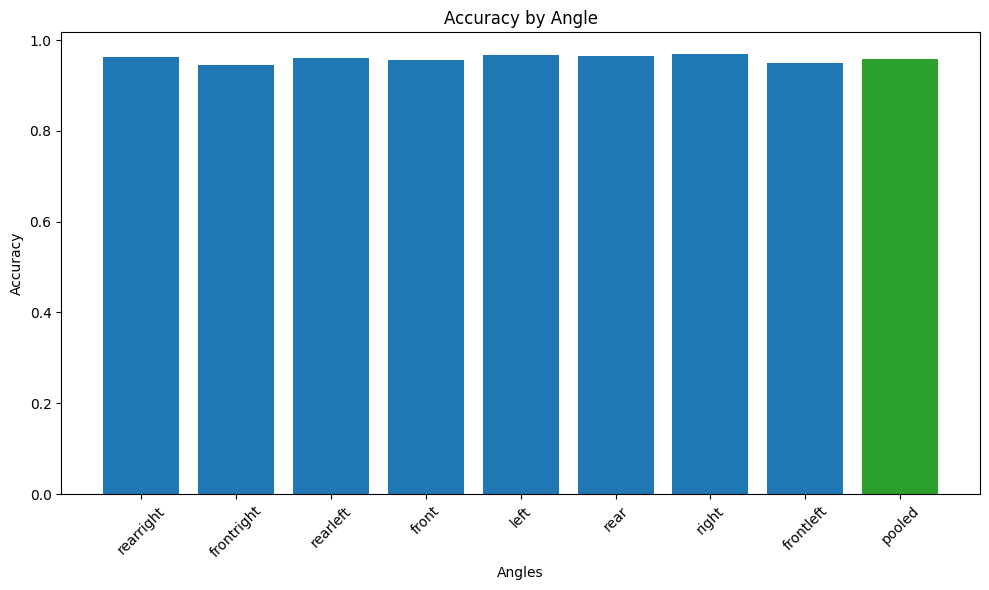

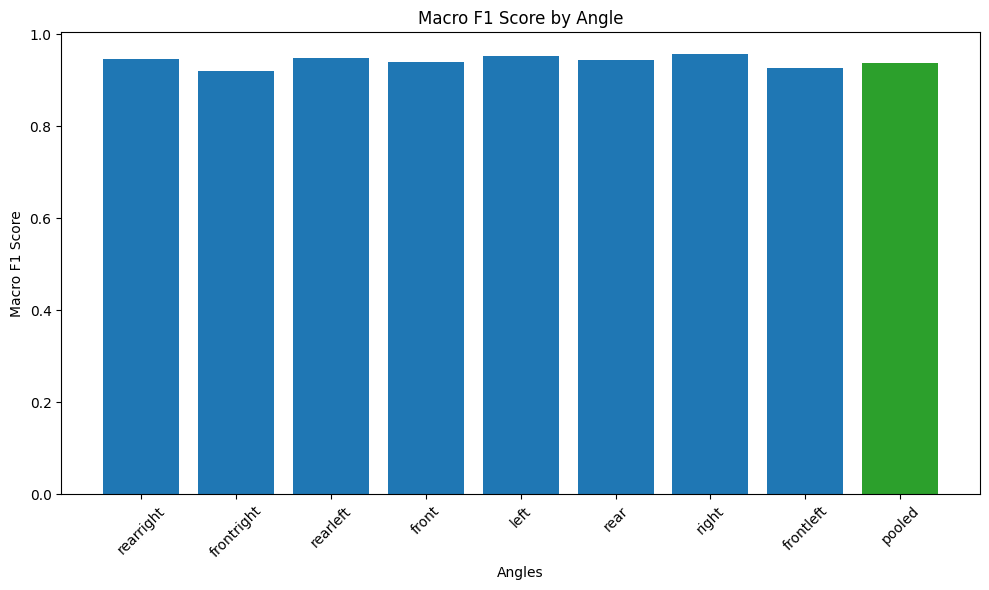

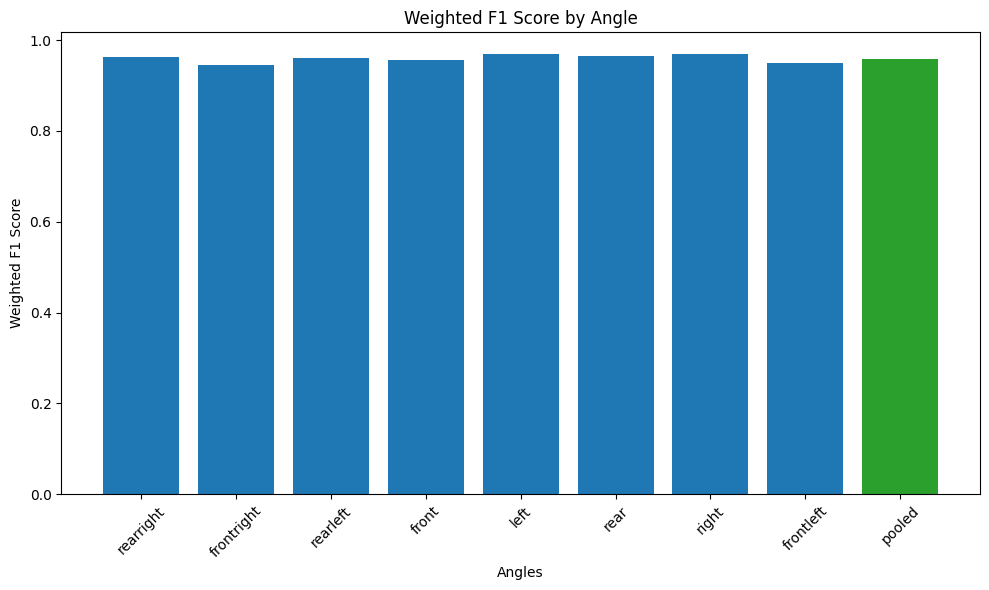

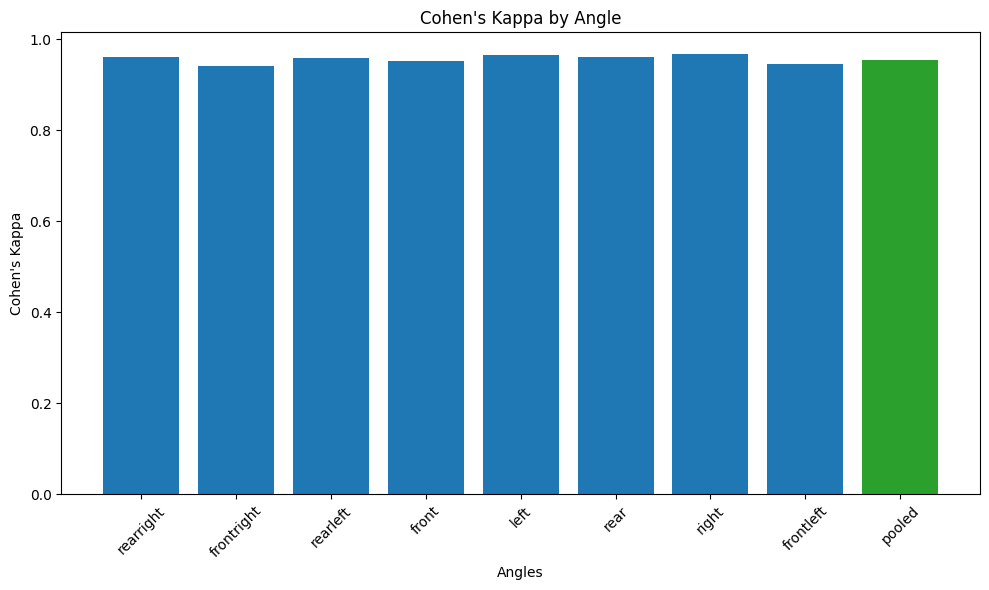

In [77]:
angles = list(angle_metrics.keys())
metrics = angle_metrics[angles[0]].keys()
color = ['tab:blue'] * (len(angles) - 1) + ['tab:green']
for metric in metrics:
    values = [angle_metrics[angle][metric] for angle in angles]
    plt.figure(figsize=(10, 6))
    plt.bar(angles, values, color=color)
    plt.title(f'{metric} by Angle')
    plt.xlabel('Angles')
    plt.ylabel(metric)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

In [44]:
angle_metrics['pooled']['Accuracy']

0.9572245847126128

We have an **accuracy** across the full validation set of **95,72%** - not bad. Let's see if we can go higher by inferring all images over all models and hard voting. We could also try other ensemble methods, but this project has been dragging on for long enough now.

## 3.6.5 Performance assessment of angle based brand models (all 8 infer)
all of the json dicts are actually the same which was to be expected using label_encoder (alhpabetical sorting is done there), so in this step we can relax and not worry about different labels being outputted by the model for different models. 

In [78]:
predictions_all = {}
actuals_all = validation_df.brand.to_list()

In [ ]:
all_infer_filename = 'all_infer.json'
all_infer_filepath = os.path.join(INFER_PATH, all_infer_filename)
if READ_INFER and os.file.exists(os.path.join(INFER_PATH, all_infer_filepath)): 
    single_infer_predicts = json.load(all_infer_filepath)
    print('INFERENCE RESULTS READ FROM DISK')
else: 
    for angle_folder in os.listdir(MODELDIR): 
        dir = os.path.join(MODELDIR, angle_folder)
        dircontent = os.listdir(dir)
        print(f'Starting predictions for {angle_folder}         ')
        model = cnn_helpers.load_one_model(dir)
        predictions_all[angle_folder] = []
        l = len(validation_df)
        for i in range(0, l, PBS):
            print(f'{i} of {l} ({i/l*100}%)', end='\r')
            batch_df = validation_df.iloc[i:i + PBS]
            X_val_images = []
            for _, row in batch_df.iterrows():
                coords = [row['yolobox_top_left_x'], row['yolobox_top_left_y'], row['yolobox_bottom_right_x'], row['yolobox_bottom_right_y']]
                image = cnn_helpers.preprocess_image(row['abs_path'], CROP, coords, SHAPE)
                X_val_images.append(image)

            X_val_images = np.array(X_val_images)
            batch_predicts = model.predict(X_val_images, verbose=0)
            predictions_all[angle_folder].extend(batch_predicts)

        # Predict for the current batch
        batch_predicts = model.predict(X_val_images, verbose=0)
        predicts.extend(batch_predicts)
        actuals.extend(y_targets)
    if STORE_INFER: 
        new_predictions_all = {}
        for k, v in predictions_all.items(): 
            new_predictions_all[k] = [arr.tolist() for arr in v]
        file_io.dict_to_json_file(
            new_predictions_all, 
            INFER_PATH, 
            all_infer_filename
        )

Starting predictions for rearright
Starting predictions for frontright%))
Starting predictions for rearleft17%))
Starting predictions for front45017%))
Starting predictions for left445017%))
Starting predictions for rear445017%))
Starting predictions for right45017%))
Starting predictions for frontleft7%))


In [101]:
with open(all_infer_filepath) as f:
    json_predicts_from_file = json.loads(f.read())

In [ ]:
max_certain_predictions = []
prediction_value_count = len(predictions_all[list(predictions_all.keys())[0]])
for i in range(prediction_value_count): 
    v = []
    for angle in predictions_all: 
        v.append(predictions_all[angle][i])
    idx = np.argmax(np.array(v).max(axis=1))
    prediction = np.argmax(v[idx])
    max_certain_predictions.append(prediction)
decoded_max_certain = [decode_labels[list(predictions_all.keys())[0]][i] for i in max_certain_predictions]


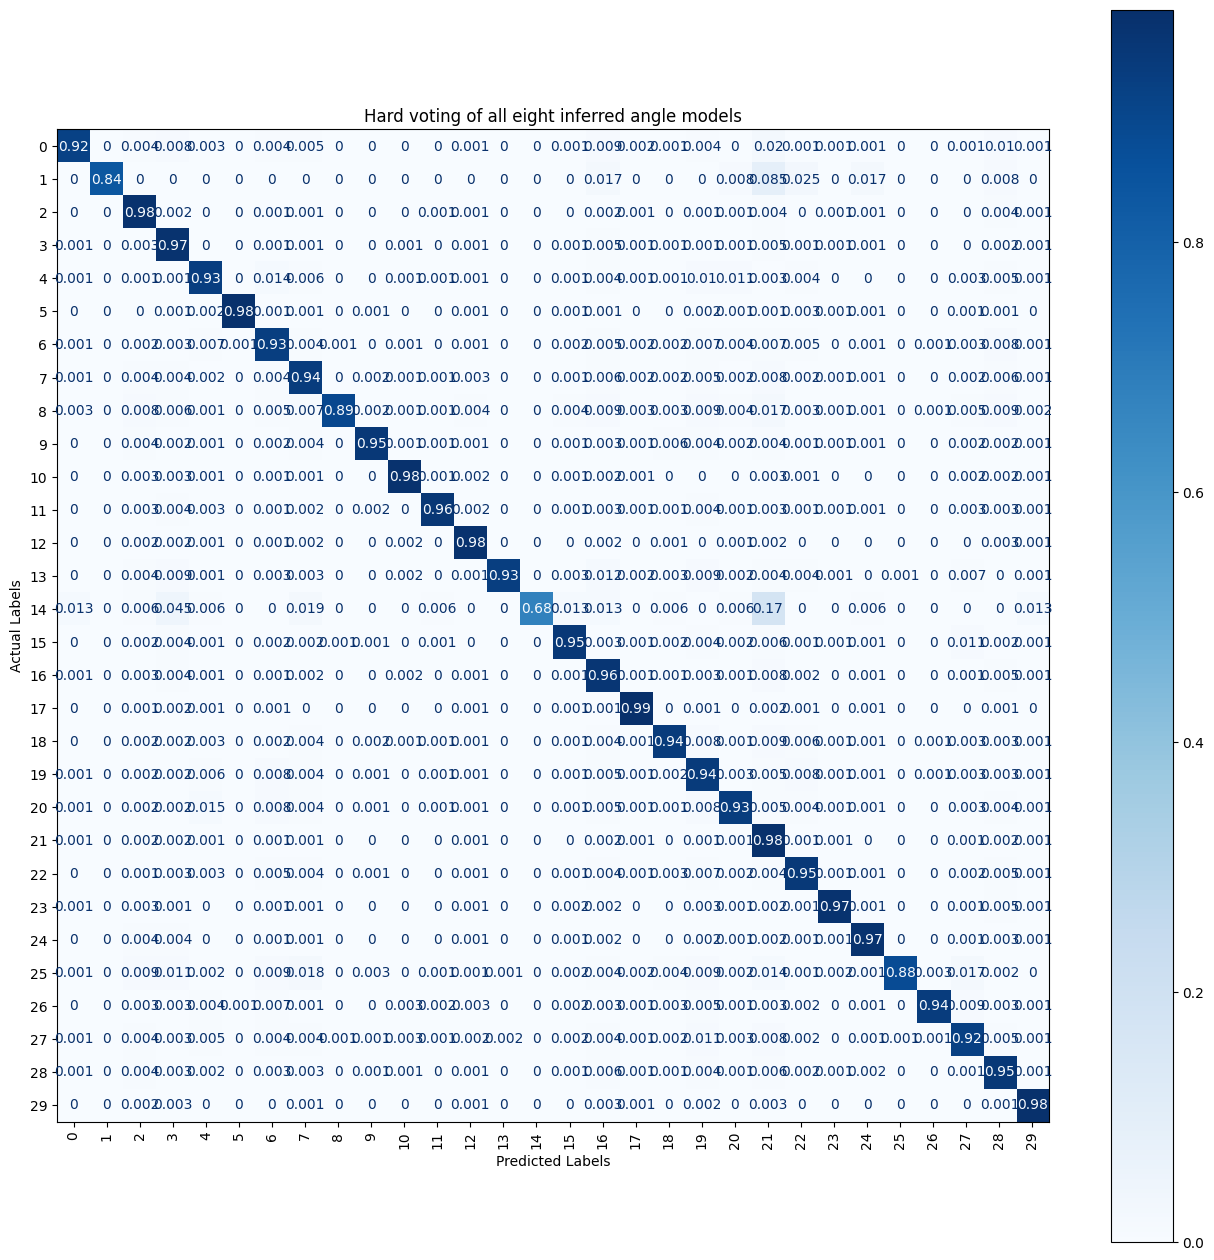

In [ ]:
all = implot.make_cm(actuals_all, decoded_max_certain, decode_labels[list(predictions_all.keys())[0]])
all.title('Hard voting of all eight inferred angle models')
all.show()

In [168]:
all_infer_metrics = quickrun_metrics(actuals_all, decoded_max_certain)

In [ ]:
#TODO: make this code less retarded
df = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1 Score', 'Weighted F1 Score', "Cohen's Kappa"],
    'Pooled': [angle_metrics['pooled']['Accuracy'], angle_metrics['pooled']['Macro F1 Score'],
               angle_metrics['pooled']['Weighted F1 Score'], angle_metrics['pooled']["Cohen's Kappa"]],
    'All': [all_infer_metrics['Accuracy'], all_infer_metrics['Macro F1 Score'],
            all_infer_metrics['Weighted F1 Score'], all_infer_metrics["Cohen's Kappa"]],
    'Diff (in favor of pooling)': [angle_metrics['pooled']['Accuracy'] - all_infer_metrics['Accuracy'],
                   angle_metrics['pooled']['Macro F1 Score'] - all_infer_metrics['Macro F1 Score'],
                   angle_metrics['pooled']['Weighted F1 Score'] - all_infer_metrics['Weighted F1 Score'],
                   angle_metrics['pooled']["Cohen's Kappa"] - all_infer_metrics["Cohen's Kappa"]]
})
df

,Metric,Pooled,All,Diff (in favor of pooling)
0,Accuracy,0.957225,0.955160,0.002065
1,Macro F1 Score,0.937986,0.939655,-0.001669
2,Weighted F1 Score,0.957270,0.955334,0.001936
3,Cohen's Kappa,0.954368,0.952158,0.002210


- slightly worse Accuracy score when using hard voting. We dropped from 95.72% to 95.51%
- Aside from the slightly worse score, you have a much worse infer time which was 8 times longer than the original infer (granted - we are using pre-computed angle-tag values).

SO NO: the specialized angle models should not be used in a simple ensemble method as used here, maybe a more advanced method may have better results. 


In [ ]:
#TODO add confidence scores of the best performing model.
#TODO add precision/recall scores of the best performing model (Maybe do this per prediction class??)
#TODO add CMs that ignore correct classifications (only show wrong classifications with Chloroplot)